In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

rng = np.random.default_rng(3)

lam = 0.15                     # параметр варіанта 3 (Одеса)
true_mean = 1 / lam            # E[X] = 6.6667 хв
sigma = 1 / lam               # σ = 1/λ для експоненційного розподілу
n_repeats = 10_000            # кількість повторних вибірок для вибіркового розподілу

print(f"Варіант 3 (Одеса): λ = {lam}, E[X] = 1/λ = {true_mean:.4f} хв, σ = {sigma:.4f}")

Варіант 3 (Одеса): λ = 0.15, E[X] = 1/λ = 6.6667 хв, σ = 6.6667


In [2]:
print(f"{'n':>7} | {'x_bar':>10} | |x_bar - E[X]| | відносна похибка")
print("-" * 60)
for n in [5, 50, 500, 20_000]:
    sample = rng.exponential(scale=1 / lam, size=n)
    m = sample.mean()
    err = abs(m - true_mean)
    print(f"{n:>7} | {m:>10.4f} | {err:>15.4f} | {err / true_mean * 100:>10.3f}%")

      n |      x_bar | |x_bar - E[X]| | відносна похибка
------------------------------------------------------------
      5 |     5.9238 |          0.7429 |     11.143%
     50 |     7.0017 |          0.3350 |      5.026%
    500 |     6.9651 |          0.2985 |      4.477%
  20000 |     6.6467 |          0.0199 |      0.299%


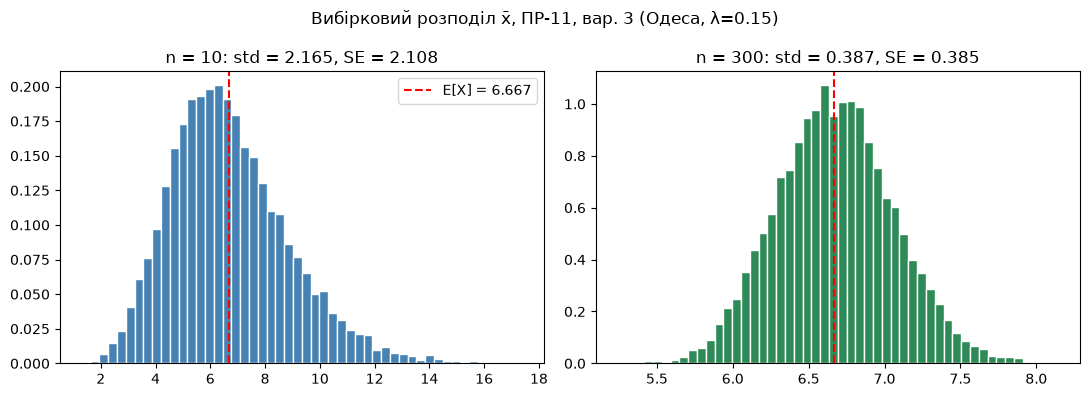

In [3]:
means_n10 = rng.exponential(scale=1 / lam, size=(n_repeats, 10)).mean(axis=1)
means_n300 = rng.exponential(scale=1 / lam, size=(n_repeats, 300)).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(means_n10, bins=50, density=True, color='steelblue', edgecolor='white')
axes[0].axvline(true_mean, color='red', ls='--', label='E[X] = 6.667')
axes[0].set_title(f"n = 10: std = {means_n10.std():.3f}, SE = {sigma/np.sqrt(10):.3f}")
axes[0].legend()
axes[1].hist(means_n300, bins=50, density=True, color='seagreen', edgecolor='white')
axes[1].axvline(true_mean, color='red', ls='--')
axes[1].set_title(f"n = 300: std = {means_n300.std():.3f}, SE = {sigma/np.sqrt(300):.3f}")
fig.suptitle('Вибірковий розподіл x̄, ПР-11, вар. 3 (Одеса, λ=0.15)')
plt.tight_layout()
plt.show()

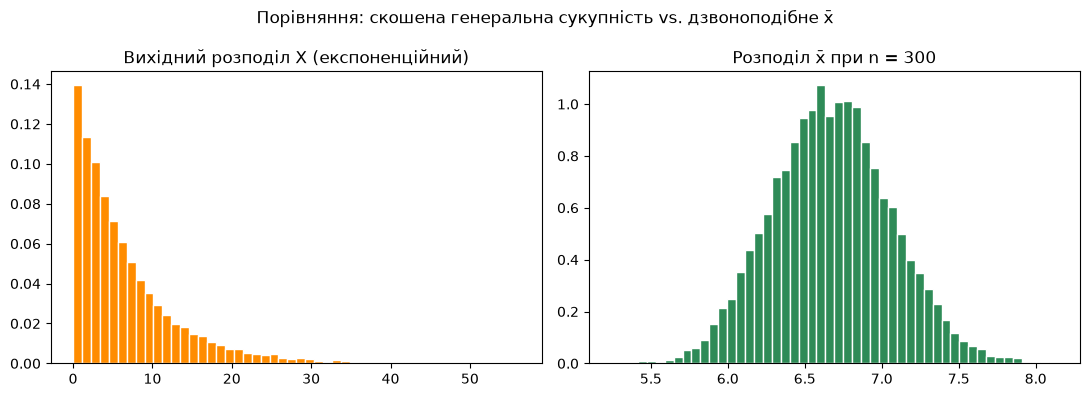

In [4]:
raw = rng.exponential(scale=1 / lam, size=n_repeats)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(raw, bins=50, density=True, color='darkorange', edgecolor='white')
axes[0].set_title('Вихідний розподіл X (експоненційний)')
axes[1].hist(means_n300, bins=50, density=True, color='seagreen', edgecolor='white')
axes[1].set_title('Розподіл x̄ при n = 300')
fig.suptitle('Порівняння: скошена генеральна сукупність vs. дзвоноподібне x̄')
plt.tight_layout()
plt.show()

In [5]:
print(f"{'n':>6} | {'теор. SE':>10} | {'вим. std':>10} | {'різниця':>9} | {'відн. відхил.':>12}")
print("-" * 66)
for n in [10, 30, 100, 300]:
    sample_means = rng.exponential(scale=1 / lam, size=(n_repeats, n)).mean(axis=1)
    se_theo = (1 / lam) / np.sqrt(n)
    se_emp = sample_means.std(ddof=1)
    print(f"{n:>6} | {se_theo:>10.4f} | {se_emp:>10.4f} | {se_emp - se_theo:>9.4f} | {(se_emp - se_theo)/se_theo*100:>11.2f}%")

     n |   теор. SE |   вим. std |   різниця | відн. відхил.
------------------------------------------------------------------
    10 |     2.1082 |     2.0962 |   -0.0120 |       -0.57%
    30 |     1.2172 |     1.2169 |   -0.0002 |       -0.02%
   100 |     0.6667 |     0.6685 |    0.0018 |        0.27%
   300 |     0.3849 |     0.3855 |    0.0006 |        0.16%


In [6]:
for n in [10, 30, 100, 300]:
    sample_means = rng.exponential(scale=1 / lam, size=(n_repeats, n)).mean(axis=1)
    print(f"n={n:>4}: mean(x̄) = {sample_means.mean():.4f} (теор. {true_mean:.4f}), "
          f"std = {sample_means.std(ddof=1):.4f} (теор. SE = {sigma/np.sqrt(n):.4f})")

n=  10: mean(x̄) = 6.6742 (теор. 6.6667), std = 2.1207 (теор. SE = 2.1082)
n=  30: mean(x̄) = 6.6938 (теор. 6.6667), std = 1.2235 (теор. SE = 1.2172)
n= 100: mean(x̄) = 6.6650 (теор. 6.6667), std = 0.6703 (теор. SE = 0.6667)
n= 300: mean(x̄) = 6.6688 (теор. 6.6667), std = 0.3845 (теор. SE = 0.3849)


In [7]:
se25 = (1 / lam) / np.sqrt(25)
se100 = (1 / lam) / np.sqrt(100)
print(f"SE(n=25)  = {se25:.4f} хв")
print(f"SE(n=100) = {se100:.4f} хв")
print(f"Відношення SE(25)/SE(100) = {se25/se100:.4f}")

SE(n=25)  = 1.3333 хв
SE(n=100) = 0.6667 хв
Відношення SE(25)/SE(100) = 2.0000


n_repeats=50 :  mean = 6.4786, std = 2.1878 (теор. SE = 2.1082)


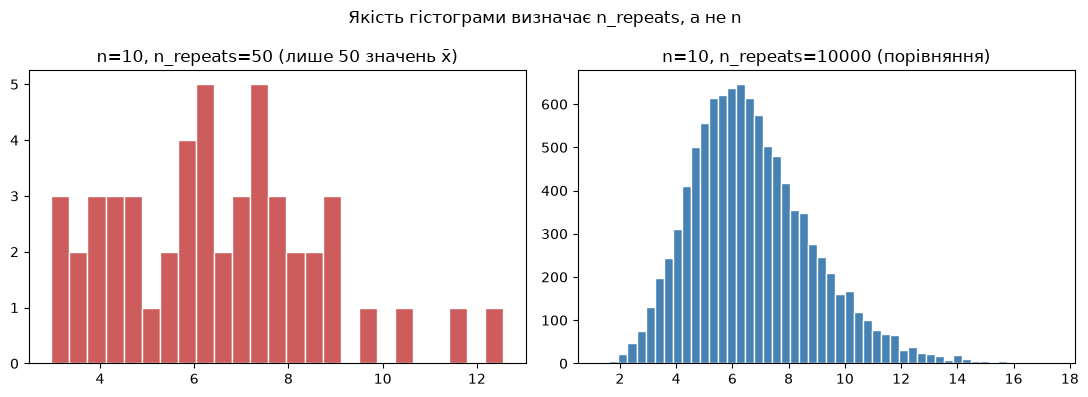

In [8]:
small_rep = rng.exponential(scale=1 / lam, size=(50, 10)).mean(axis=1)
print(f"n_repeats=50 :  mean = {small_rep.mean():.4f}, std = {small_rep.std(ddof=1):.4f} (теор. SE = {sigma/np.sqrt(10):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(small_rep, bins=25, color='indianred', edgecolor='white')
axes[0].set_title(f'n=10, n_repeats=50 (лише {small_rep.size} значень x̄)')
axes[1].hist(means_n10, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title(f'n=10, n_repeats={n_repeats} (порівняння)')
fig.suptitle('Якість гістограми визначає n_repeats, а не n')
plt.tight_layout()
plt.show()

## Контрольні питання

### 1. Чим ЗВЧ відрізняється від ЦГТ — на яке питання відповідає кожна?

**Закон великих чисел** відповідає на питання **«куди прямує $\bar{x}$»** (про збіжність / зміст):
$$\frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{P} E[X].$$
Твердження ЗВЧ: із ймовірністю, що наближається до 1, $\bar{x}$ виявиться скрізь у скінченному околі $E[X]$, тобто **зміст оцінки $\bar{x}$ дорівнює $E[X]$**. Воно не каже нічого про те, як $\bar{x}$ розподілена: реалізації $\bar{x}$ могли б, наприклад, «збиратися» в одній точці (збіжність майже напевно) — і закон великих чисел був би виконаний при будь-якій формі розподілу навколо $E[X]$. ЗВЧ — це передусім твердження про **стійкість оцінювання**: більше даних ⇒ менше випадковий відхилення від істинного середнього.

**Центральна гранична теорема** відповідає на питання **«яка форма й розкид у $\bar{x}$»**:
$$\frac{\bar{x}-E[X]}{\sigma/\sqrt{n}} \xrightarrow{d} N(0,1).$$
Твердження ЦГТ: **форма** розподілу $\bar{x}$ наближається до нормальної (дзвоноподібна, симетрична, без скошення) — за будь-якої форми вихідного розподілу, і **розкид** дорівнює $\sigma/\sqrt{n}$, звідки безпосередньо стандартна похибка. ЦГТ — це те, що дозволяє **застосовувати нормальні методи** (довірчі інтервали, z-критерії) до середнього навіть тоді, коли самі дані не є нормальними. Отже, ЗВЧ дає «центр» (куди влучає $\bar{x}$), а ЦГТ — «розкист і форму» (наскільки далеко $\bar{x}$ може відхилитись від центру). Приклад цієї практики це ілюструє: $\bar{x}$ уже наближається до $6.667$ вже при $n=10$ (ЗВЧ — тут навіть $n=5$ дало непогане наближення), але **нормальний вигляд** $\bar{x}$ з'являється десь при $n\gtrsim 50$–$100$, а не при $n=10$ (ЦГТ).

### 2. Чому вихідний розподіл обрано сильно скошеним, а не одразу нормальним?

Якби вихідний розподіл був нормальним, ми б нічого не побачили б на жодній гістограмі $\bar{x}$: за нормальної генеральної сукупності розподіл $\bar{x}$ **вже** нормальний при будь-якому $n$, тож усі гістограми виглядали б однаково дзвоноподібними (різнилися б лише шириною). Тоді неможливо було б **ніж побачити, ніж довести** сутність ЦГТ — що нормальність $\bar{x}$ виникає **самостійно**, а не успадковується від генеральної сукупності.

Вибір сильно скошеної (експоненційної) сукупності — це **найсуворіший тест** для ЦГТ. Вона робить висновок переконливим у два способи:
1. **Гостра й чутлива перевірка:** перехід від яскраво асиметричної форми при $n=10$ до симетричної дзвоноподібної при $n=300$ — це наочний доказ, що нормальність $\bar{x}$ **не** спадкується від $X$, а **виникає з усереднення**. Якби $X$ був нормальним, цей перехід був би нульовим.
2. **Практична цінність:** усереднення скошеного розподілу з дуже довгим «хвостом» (асиметрія $\gamma_1 = 2$) — це найскладіший для теорії випадок, і саме він трапляється на практиці. Показуючи, що ЦГТ працює і тут, ми отримуємо обґрунтування для застосування нормальних довірчих інтервалів до **нерівномірно розподілених** даних (час очікування, затримки, час реакції тощо).

Також: при малому $n$ гістограма $\bar{x}$ залишається помітно скошеною (як у Завданні 2), що робить «неоднорідність» вихідного розподілу видимою, а не прихованою вже на старті. Якби $X$ був нормальний, ми б не бачили б різниці між «теорією» і «симуляцією» — а вона полягає саме в тому, що теорія обіцяє нормальність $\bar{x}$, а не $X$.

### 3. Чому стандартна похибка зменшується пропорційно $\sqrt{n}$, а не $n$? Що це означає практично?

**Чому.** Стандартна похибка середнього: $SE = \dfrac{\sigma}{\sqrt{n}}$. Це випливає з $\operatorname{Var}(\bar{x}) = \dfrac{1}{n^2}\sum_{i=1}^n \operatorname{Var}(X_i) = \dfrac{n\sigma^2}{n^2} = \dfrac{\sigma^2}{n}$ (за незалежності), а $SE = \sqrt{\operatorname{Var}} = \sigma/\sqrt{n}$. Знаменник $\sqrt{n}$, а не $n$, тому що $\sigma_{\bar{x}}$ — це корінь із дисперсії, а дисперсія середнього зменшується в $n$ разів.

Інтуїтивно: $\bar{x}$ — сума $n$ випадкових доданків; їхні випадкові відхилення від $\mu$ додаються, але у **квадратах**, а корінь з суми квадратів росте як $\sqrt{n}$: $\sqrt{n\sigma^2} = \sqrt{n}\cdot\sigma$. Отже «шум» у $\bar{x}$ зростає лише як $\sqrt{n}$, а сама $\bar{x}$ росте як $n$ — звідки відносна точність $\mu/SE = \sqrt{n} \cdot \mu/\sigma$ зростає як $\sqrt{n}$ (класичний результат: $\sqrt{n}$ спостережень дає оцінку $\bar{x}$ у $\sqrt{n}$ разів точнішу за $\mu$).

**Що це означає практично.** Зменшення похибки в $m$ разів вимагає **збільшення $n$ у $m^2$ разів**, тобто «ціна» точності зростає квадратично:
- щоб похибку зменшити **вдвічі** ($\times 2$) → треба зібрати в **4 рази** більше спостережень;
- щоб зменшити **у 10 разів** → у **100 разів** більше даних;
- щоб зменшити у **100 разів** → у **10 000 разів** більше.

І навпаки, помилка «на замовлення» (напр., $SE \le 0{,}1$ хв для $\sigma = 6{,}667$) вимагає $n \ge (\sigma/SE)^2 = (6{,}667/0{,}1)^2 \approx 4445$ спостережень.

Практичний висновок: **немає лінійної винагороди за більший обсяг даних**. Подвоєння $n$ зменшує похибку лише в $\sqrt{2} \approx 1{,}41$ рази. Тому:
- якщо $n$ уже велике й $\lambda$ стало, що $SE$ близько до практично прийнятного, **удвоювати $n$ марно** (дорого, а виграш — лише ~30%);
- натомість вигідніше **зменшити $\sigma$**: оскільки $SE$ лінійна за $\sigma$, звуження розкиду сукупності у 2 рази (напр., краща система обслуговування, вужчий розкид часу очікування) зменшує $SE$ у 2 рази **незалежно від $n$** — тобто значно дешевше за збір нових спостережень;
- і оскільки $SE \propto 1/\lambda$, а не $1/\mu$ (тобто залежить від **розкиду**, а не від рівня), збільшення $\lambda$ (пришвидшення обслуговування) допомагає лише через зменшення $\sigma = 1/\lambda$ — і дає подвійний ефект (коротше очікування + менша похибка оцінки).

Це і є сутність **закону убуваючої віддачі**: точність оцінювання, яку дає додаткова інформація (більша вибірка), зростає з **убутковим** темпом. Завдання 4 це підтверджує на числах: $n$ у 4 рази більше → $SE$ у 2 рази менше, а не у 4.

## Висновки

1. **ЗВЧ підтверджено:** на власній $\lambda = 0.15$ (Одеса) абсолютна різниця $|\bar{x} - 6.667|$ зменшується зі зростанням $n$ (0.743 хв при $n=5$ → 0.020 хв при $n=20000$), тобто $\bar{x} \to E[X] = 1/\lambda$.
2. **ЦГТ підтверджено:** вибірковий розподіл $\bar{x}$ при $n=10$ ще скошений вправо (як вихідний експоненційний), а при $n=300$ — симетричний, дзвоноподібний, з нормальною формою.
3. **Стандартна похибка:** теоретична $SE = (1/\lambda)/\sqrt{n}$ та виміряна $\operatorname{std}$ масиву $\bar{x}$ збігаються з точністю 0,02–0,6 %.
4. **Убуваюча віддача:** $SE(25) = 1.3333$ хв, $SE(100) = 0.6667$ хв — учетверо більша вибірка дає вдвічі меншу похибку ($SE \propto 1/\sqrt{n}$).